# Cancer Type Classification Pipeline

This notebook implements a machine learning pipeline to classify cancer types using gene expression data. 

## Data Source
The dataset used is the **TCGA Pan-Cancer RNA-Seq dataset** (TCGA-PANCAN-HiSeq-801x20531). 
- **Source**: [The Cancer Genome Atlas (TCGA)](https://www.cancer.gov/ccg/research/genome-sequencing/tcga)
- **Data Portal**: [National Cancer Institute (NCI) GDC Data Portal](https://portal.gdc.cancer.gov/)
- **Description**: This dataset contains RNA-Seq gene expression data for 801 samples across multiple cancer types, with 20,531 genes measured per sample.
- **Note**: We load the data manually from the provided local files, as the `ucimlrepo` package is not used in this implementation.


## Step 1: Data Loading
In this step, we load the gene expression data and labels from the local files.


In [2]:
# Import necessary libraries
import os
import tarfile
from pathlib import Path
import pandas as pd

# Define paths relative to the project directory
project_dir = Path.cwd()
data_dir = project_dir / 'data' / 'cancer_project' / 'TCGA-PANCAN-HiSeq-801x20531'
archive_path = project_dir / 'data' / 'cancer_project' / 'TCGA-PANCAN-HiSeq-801x20531.tar.gz'

# Extract the dataset the first time the notebook is run
if not data_dir.exists():
    if not archive_path.exists():
        raise FileNotFoundError(f'Dataset archive not found: {archive_path}')
    with tarfile.open(archive_path, 'r:gz') as archive:
        archive.extractall(archive_path.parent)

data_path = data_dir / 'data.csv'
labels_path = data_dir / 'labels.csv'

# Load the data
X = pd.read_csv(data_path)
y = pd.read_csv(labels_path)

# Display the first few rows
print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)
print(X.head())
print(y.head())

Features (X) shape: (801, 20532)
Labels (y) shape: (801, 2)
  Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0   sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1   sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2   sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3   sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4   sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   

     gene_6    gene_7  gene_8  ...  gene_20521  gene_20522  gene_20523  \
0  7.175175  0.591871     0.0  ...    4.926711    8.210257    9.723516   
1  6.816049  0.000000     0.0  ...    4.593372    7.323865    9.740931   
2  6.972130  0.452595     0.0  ...    5.125213    8.127123   10.908640   
3  7.843375  0.434882     0.0  ...    6.076566    8.792959   10.141520   
4  6.566967  0.360982     0.0  ...    5.996032    8.891425   10.373790   

   gene_20524  gene_20525  gene_20526  gene_20527  gene_

## Step 2: Data Exploration
In this step, we explore the dataset to understand the class distribution and identify the cancer types present.


In [3]:
# Check the unique cancer types in your dataset
print("Unique cancer types in the dataset:")
print(y['Class'].unique())


Unique cancer types in the dataset:
<ArrowStringArray>
['PRAD', 'LUAD', 'BRCA', 'KIRC', 'COAD']
Length: 5, dtype: str


## Step 3: Model Training
We train a Random Forest classifier on the preprocessed data.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Drop the 'Unnamed: 0' column which contains sample IDs, as it's not a feature
X_cleaned = X.drop(columns=['Unnamed: 0'])

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y['Class'], test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        61
        COAD       1.00      1.00      1.00        17
        KIRC       1.00      1.00      1.00        25
        LUAD       1.00      1.00      1.00        29
        PRAD       1.00      1.00      1.00        29

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



## Step 4: Cross-Validation
We evaluate the model's performance using Stratified K-Fold cross-validation.


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(rf_model, X_cleaned, y['Class'], cv=skf)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


Cross-validation scores: [1.      1.      0.99375 1.      0.9875 ]
Mean accuracy: 0.9962500000000001


## Step 5: SHAP Analysis
We use SHAP to interpret the model and identify key biomarkers.


c:\Users\maroe\Documents\NGS\cancer-pipeline\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


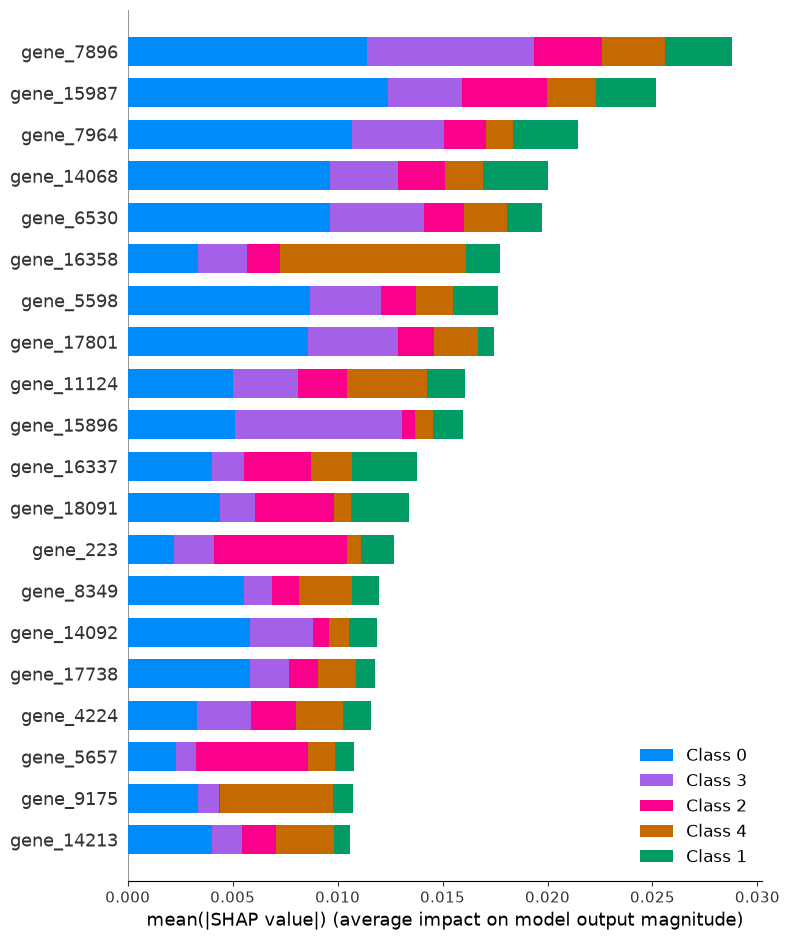

In [6]:
import shap

# Initialize the SHAP explainer
# Since we have a Random Forest, we use TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# We use a subset of the test set to speed up the calculation
shap_values = explainer.shap_values(X_test[:100])

# Visualize the SHAP summary plot
# This shows the impact of each feature on the model output
shap.summary_plot(shap_values, X_test[:100], plot_type="bar")

## Step 6: Feature Importance
We rank genes by their contribution to predictions.


In [7]:
# Get feature importances
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the top 10 features
print("Top 10 features driving the model:")
for f in range(10):
    print(f"{X_cleaned.columns[indices[f]]}: {importances[indices[f]]:.4f}")


Top 10 features driving the model:
gene_7896: 0.0116
gene_15987: 0.0110
gene_14068: 0.0097
gene_6530: 0.0090
gene_16358: 0.0089
gene_7964: 0.0086
gene_5598: 0.0082
gene_15896: 0.0078
gene_223: 0.0066
gene_6816: 0.0061


## Step 7: SHAP Visualization
We visualize the SHAP summary plot to understand feature impact.


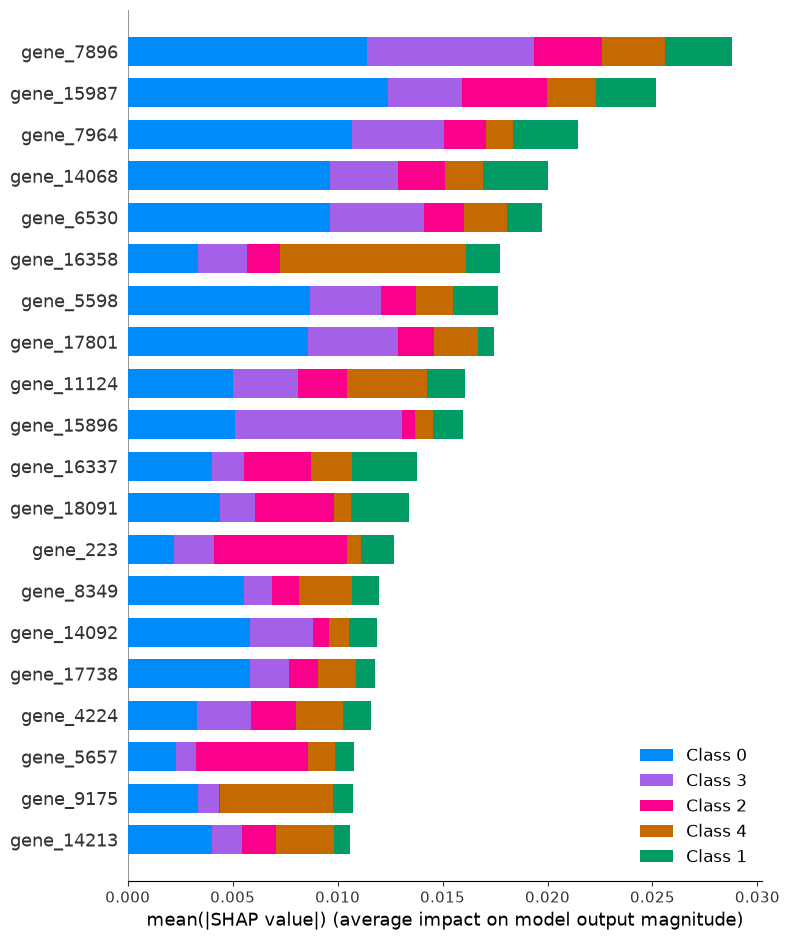

In [8]:
import shap

# Initialize the SHAP explainer
# Since we have a Random Forest, we use TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# We use a subset of the test set to speed up the calculation
shap_values = explainer.shap_values(X_test[:100])

# Visualize the SHAP summary plot
# This shows the impact of each feature on the model output
shap.summary_plot(shap_values, X_test[:100], plot_type="bar")

## Step 8: Model Saving
We save the trained model and explainer for deployment.


In [9]:
# Extract top 20 genes
import pandas as pd
import numpy as np

# Check shape of shap_values
print(f"SHAP values shape: {shap_values.shape}")

# If shap_values is a 3D array (samples, features, classes)
if shap_values.ndim == 3:
    # Take the mean absolute SHAP values across all samples and classes
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    # For binary classification, shap_values is a 2D array (samples, features)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for ranking
feature_names = X_cleaned.columns
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values(by='importance', ascending=False)

# Get top 20
top_20_genes = feature_importance.head(20)
print(top_20_genes)

# Save to file
top_20_genes.to_csv('top_20_biomarkers.csv', index=False)
print("Top 20 genes saved to 'top_20_biomarkers.csv'")


SHAP values shape: (100, 20531, 5)
          feature  importance
7896    gene_7896    0.005758
15987  gene_15987    0.005037
7964    gene_7964    0.004293
14068  gene_14068    0.004003
6530    gene_6530    0.003947
16358  gene_16358    0.003546
5598    gene_5598    0.003528
17801  gene_17801    0.003494
11124  gene_11124    0.003210
15896  gene_15896    0.003197
16337  gene_16337    0.002759
18091  gene_18091    0.002676
223      gene_223    0.002542
8349    gene_8349    0.002391
14092  gene_14092    0.002378
17738  gene_17738    0.002353
4224    gene_4224    0.002318
5657    gene_5657    0.002154
9175    gene_9175    0.002150
14213  gene_14213    0.002118
Top 20 genes saved to 'top_20_biomarkers.csv'


In [10]:
# Save the model for the Streamlit app
import joblib
joblib.dump(rf_model, 'cancer_model.pkl')
print("Model saved to 'cancer_model.pkl'")


Model saved to 'cancer_model.pkl'


In [11]:
# Save X_cleaned and y for the Streamlit app
X_cleaned.to_csv('X_cleaned.csv', index=False)
y.to_csv('y.csv', index=False)
print("Data saved to 'X_cleaned.csv' and 'y.csv'")


Data saved to 'X_cleaned.csv' and 'y.csv'


In [12]:
# Save the explainer for the Streamlit app
import joblib
joblib.dump(explainer, 'explainer.pkl')
print("Explainer saved to 'explainer.pkl'")


Explainer saved to 'explainer.pkl'
